#OBJETIVO


In [15]:
# Librerías para limpieza de texto
import unicodedata as una
import re

# Librerías para manejo de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
import os
os.listdir("/content")

['.config',
 'articles-421541_recurso.xlsx',
 '.ipynb_checkpoints',
 'sample_data']

In [23]:
df = pd.read_excel(NOMBRE_ARCHIVO, sheet_name=HOJA, engine="openpyxl")
print(f"Filas originales: {len(df):,}")
df.head()

Filas originales: 49,271


,CÓDIGO DE LA INSTITUCIÓN,IES PADRE,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES),TIPO IES,ID SECTOR IES,SECTOR IES,ID CARÁCTER IES,CARÁCTER IES,CÓDIGO DEL DEPARTAMENTO (IES),DEPARTAMENTO DE DOMICILIO DE LA IES,...,DESC CINE CAMPO DETALLADO,CÓDIGO DEL DEPARTAMENTO (PROGRAMA),DEPARTAMENTO DE OFERTA DEL PROGRAMA,CÓDIGO DEL MUNICIPIO (PROGRAMA),MUNICIPIO DE OFERTA DEL PROGRAMA,ID SEXO,SEXO,AÑO,SEMESTRE,MATRICULADOS PRIMER CURSO
0,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Producción agrícola y ganadera,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",1.0,Masculino,2023.0,1.0,63.0
1,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Producción agrícola y ganadera,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",1.0,Masculino,2023.0,2.0,49.0
2,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Producción agrícola y ganadera,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",2.0,Femenino,2023.0,1.0,37.0
3,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Producción agrícola y ganadera,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",2.0,Femenino,2023.0,2.0,31.0
4,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Veterinaria,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",1.0,Masculino,2023.0,1.0,15.0


In [27]:
def limpiar_texto(valor):
    """Normaliza texto: sin tildes, sin ñ, sin caracteres especiales, en MAYÚSCULAS."""

    # Si el valor es NaN (vacío), lo dejamos igual, no tiene sentido "limpiar" un vacío
    if pd.isna(valor):
        return valor

    texto = str(valor)  # aseguramos que sea texto, por si viene como número u otro tipo

    # Descompone letras con tilde/diéresis/ñ en su letra base + el acento como caracter aparte
    # ej: "Á" -> "A" + acento ; "Ñ" -> "N" + tilde
    texto = una.normalize("NFKD", texto)

    # Eliminamos esos acentos ya separados, quedándonos solo con la letra base
    texto = "".join(c for c in texto if not una.combining(c))

    # Convertimos todo a mayúsculas para evitar duplicados por formato (ej: "Bogota" vs "BOGOTA")
    texto = texto.upper()

    # Eliminamos cualquier caracter que no sea letra, número o espacio (puntos, comas, símbolos, etc.)
    texto = re.sub(r"[^A-Z0-9\s]", " ", texto)

    # Colapsamos múltiples espacios en uno solo y quitamos espacios al inicio/final
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


In [29]:
# Columnas de texto que necesitan normalización (nombres consistentes para agrupar/filtrar)
columnas_texto = [
    "MUNICIPIO DE OFERTA DEL PROGRAMA",
    "DEPARTAMENTO DE OFERTA DEL PROGRAMA",
    "NIVEL DE FORMACIÓN",
    "SEXO",
    "ÁREA DE CONOCIMIENTO",
    "INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)",
]

# Creamos una versión "_LIMPIO" de cada columna, dejando la original intacta por si acaso
for col in columnas_texto:
    df[col + "_LIMPIO"] = df[col].apply(limpiar_texto)

# Convertimos la columna de matriculados a numérico (por si vino como texto)
# errors="coerce" convierte en NaN cualquier valor que no se pueda transformar a número
df["MATRICULADOS PRIMER CURSO"] = pd.to_numeric(df["MATRICULADOS PRIMER CURSO"], errors="coerce")

# Eliminamos filas donde no se pudo obtener un número válido de matriculados
df = df.dropna(subset=["MATRICULADOS PRIMER CURSO"])

# Vista rápida de las columnas limpias para verificar que la normalización funcionó bien
df[[c for c in df.columns if "_LIMPIO" in c]].head()

,MUNICIPIO DE OFERTA DEL PROGRAMA_LIMPIO,DEPARTAMENTO DE OFERTA DEL PROGRAMA_LIMPIO,NIVEL DE FORMACIÓN_LIMPIO,SEXO_LIMPIO,ÁREA DE CONOCIMIENTO_LIMPIO,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)_LIMPIO
0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
1,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
2,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,FEMENINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
3,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,FEMENINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
4,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,AGRONOMIA VETERINARIA Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA


In [31]:
# Filtramos el dataframe para quedarnos solo con:
# - Municipio = Bogotá D.C. (usando la columna ya limpia y normalizada)
# - Año = 2023
df_bog = df[
    (df["MUNICIPIO DE OFERTA DEL PROGRAMA_LIMPIO"] == "BOGOTA D C")
    & (df["AÑO"] == 2023)
].copy()  # .copy() evita warnings de pandas al modificar este subconjunto más adelante

# Verificamos cuántas filas quedaron tras el filtro (control de calidad)
print(f"Filas filtradas para Bogotá 2023: {len(df_bog):,}")
print(f"Total estudiantes matriculados: {df_bog['MATRICULADOS PRIMER CURSO'].sum():,.0f}")

# Vista rápida del subconjunto filtrado
df_bog.head()

Filas filtradas para Bogotá 2023: 12,056
Total estudiantes matriculados: 397,083


,CÓDIGO DE LA INSTITUCIÓN,IES PADRE,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES),TIPO IES,ID SECTOR IES,SECTOR IES,ID CARÁCTER IES,CARÁCTER IES,CÓDIGO DEL DEPARTAMENTO (IES),DEPARTAMENTO DE DOMICILIO DE LA IES,...,SEXO,AÑO,SEMESTRE,MATRICULADOS PRIMER CURSO,MUNICIPIO DE OFERTA DEL PROGRAMA_LIMPIO,DEPARTAMENTO DE OFERTA DEL PROGRAMA_LIMPIO,NIVEL DE FORMACIÓN_LIMPIO,SEXO_LIMPIO,ÁREA DE CONOCIMIENTO_LIMPIO,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)_LIMPIO
0,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Masculino,2023.0,1.0,63.0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
1,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Masculino,2023.0,2.0,49.0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
2,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Femenino,2023.0,1.0,37.0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,FEMENINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
3,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Femenino,2023.0,2.0,31.0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,FEMENINO,INGENIERIA ARQUITECTURA URBANISMO Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA
4,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",...,Masculino,2023.0,1.0,15.0,BOGOTA D C,BOGOTA D C,UNIVERSITARIO,MASCULINO,AGRONOMIA VETERINARIA Y AFINES,UNIVERSIDAD NACIONAL DE COLOMBIA


NIVEL DE FORMACIÓN_LIMPIO
UNIVERSITARIO                          166830.0
TECNOLOGICO                            119731.0
ESPECIALIZACION UNIVERSITARIA           55874.0
FORMACION TECNICA PROFESIONAL           31365.0
MAESTRIA                                21052.0
ESPECIALIZACION MEDICO QUIRURGICA        1135.0
DOCTORADO                                 786.0
ESPECIALIZACION TECNOLOGICA               270.0
ESPECIALIZACION TECNICO PROFESIONAL        40.0
Name: MATRICULADOS PRIMER CURSO, dtype: float64


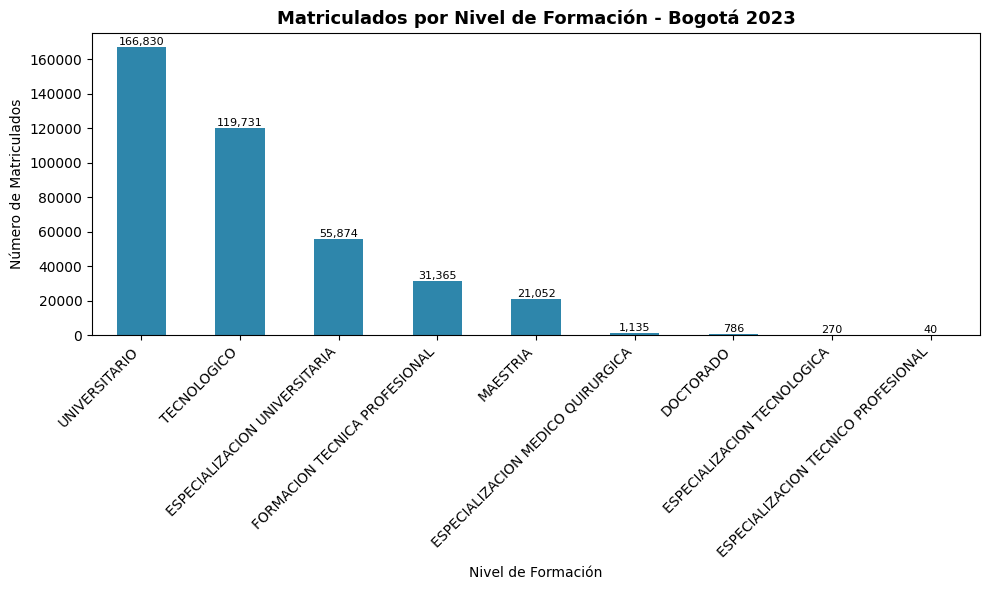

In [32]:
# Agrupamos por nivel de formación y sumamos los matriculados de cada categoría
matriculados_nivel = (
    df_bog.groupby("NIVEL DE FORMACIÓN_LIMPIO")["MATRICULADOS PRIMER CURSO"]
    .sum()
    .sort_values(ascending=False)  # ordenamos de mayor a menor para que el gráfico sea más legible
)
print(matriculados_nivel)

# Creamos la figura y el eje del gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
matriculados_nivel.plot(kind="bar", color="#2E86AB", ax=ax)

# Título y etiquetas de los ejes
ax.set_title("Matriculados por Nivel de Formación - Bogotá 2023", fontsize=13, fontweight="bold")
ax.set_xlabel("Nivel de Formación")
ax.set_ylabel("Número de Matriculados")
plt.xticks(rotation=45, ha="right")  # rotamos las etiquetas para que no se encimen

# Agregamos el valor exacto encima de cada barra (mejora la lectura del gráfico)
for i, valor in enumerate(matriculados_nivel):
    ax.text(i, valor, f"{valor:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()  # ajusta márgenes para que no se corten etiquetas
plt.show()

SEXO_LIMPIO
FEMENINO      204029.0
MASCULINO     193053.0
NO BINARIO         1.0
Name: MATRICULADOS PRIMER CURSO, dtype: float64


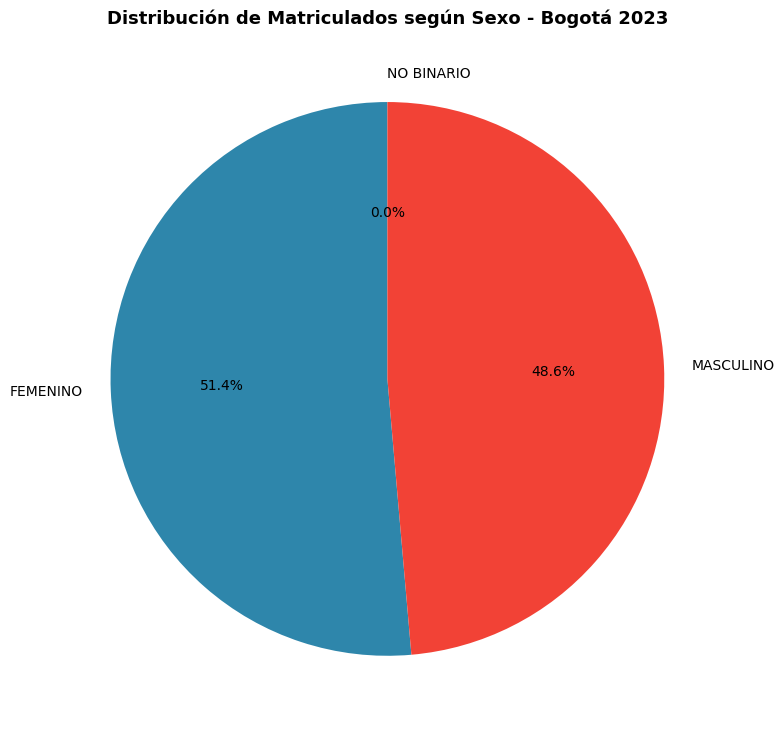

In [35]:
import matplotlib.pyplot as plt

# --- 1. PROCESAMIENTO Y AGRUPACIÓN DE DATOS ---

# Agrupar por la columna 'SEXO_LIMPIO', calcular la suma total de matriculados
# de primer curso para cada categoría y ordenar los resultados de mayor a menor
matriculados_sexo = (
    df_bog.groupby("SEXO_LIMPIO")["MATRICULADOS PRIMER CURSO"]
    .sum()
    .sort_values(ascending=False)
)

# Imprimir el resultado agrupado en la consola
print(matriculados_sexo)


# --- 2. GENERACIÓN DEL GRÁFICO ---

# Crear la figura y los ejes de la gráfica con un tamaño cuadrado (8x8 pulgadas)
fig, ax = plt.subplots(figsize=(8, 8))

# Definir una paleta de colores personalizada en formato Hexadecimal
colores = ["#2E86AB", "#F24236", "#F6AE2D", "#5B8C5A"]

# Dibujar el gráfico de pastel (pie chart)
ax.pie(
    matriculados_sexo,
    labels=matriculados_sexo.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colores[: len(matriculados_sexo)],
    textprops={"fontsize": 10},
)

# Configurar el título del gráfico con tamaño de fuente e intensidad en negrita
ax.set_title("Distribución de Matriculados según Sexo - Bogotá 2023", fontsize=13, fontweight="bold")

# Ajustar automáticamente los márgenes de la figura para evitar superposiciones
plt.tight_layout()

# Renderizar y mostrar el gráfico en pantalla
plt.show()

In [36]:
# --- TABLA CRUZADA / TABLA DINÁMICA DE MATRICULADOS ---

# Crear una tabla dinámica para analizar la distribución de estudiantes de primer curso,
# cruzando las áreas de conocimiento (filas) con los niveles de formación (columnas)
tabla_cruzada = pd.pivot_table(
    df_bog,
    values="MATRICULADOS PRIMER CURSO",
    index="ÁREA DE CONOCIMIENTO_LIMPIO",
    columns="NIVEL DE FORMACIÓN_LIMPIO",
    aggfunc="sum",
    fill_value=0,
)

# Mostrar la tabla dinámica resultante
tabla_cruzada

NIVEL DE FORMACIÓN_LIMPIO,DOCTORADO,ESPECIALIZACION MEDICO QUIRURGICA,ESPECIALIZACION TECNICO PROFESIONAL,ESPECIALIZACION TECNOLOGICA,ESPECIALIZACION UNIVERSITARIA,FORMACION TECNICA PROFESIONAL,MAESTRIA,TECNOLOGICO,UNIVERSITARIO
ÁREA DE CONOCIMIENTO_LIMPIO,,,,,,,,,
AGRONOMIA VETERINARIA Y AFINES,12.0,0.0,0.0,5.0,335.0,0.0,58.0,12.0,1550.0
BELLAS ARTES,4.0,0.0,0.0,0.0,392.0,3659.0,234.0,2643.0,7425.0
CIENCIAS DE LA EDUCACION,85.0,0.0,0.0,126.0,4887.0,0.0,4610.0,331.0,8723.0
CIENCIAS DE LA SALUD,42.0,1030.0,0.0,0.0,1404.0,38.0,798.0,1350.0,7467.0
CIENCIAS SOCIALES Y HUMANAS,221.0,0.0,29.0,2.0,9909.0,1705.0,3067.0,1500.0,24852.0
ECONOMIA ADMINISTRACION CONTADURIA Y AFINES,51.0,0.0,0.0,50.0,17997.0,11684.0,3202.0,16795.0,45075.0
INGENIERIA ARQUITECTURA URBANISMO Y AFINES,121.0,0.0,11.0,76.0,3605.0,11902.0,2292.0,12284.0,35428.0
MATEMATICAS Y CIENCIAS NATURALES,75.0,0.0,0.0,0.0,393.0,0.0,577.0,417.0,3047.0
SIN INFORMACION,175.0,105.0,0.0,11.0,16952.0,2377.0,6214.0,84399.0,33263.0


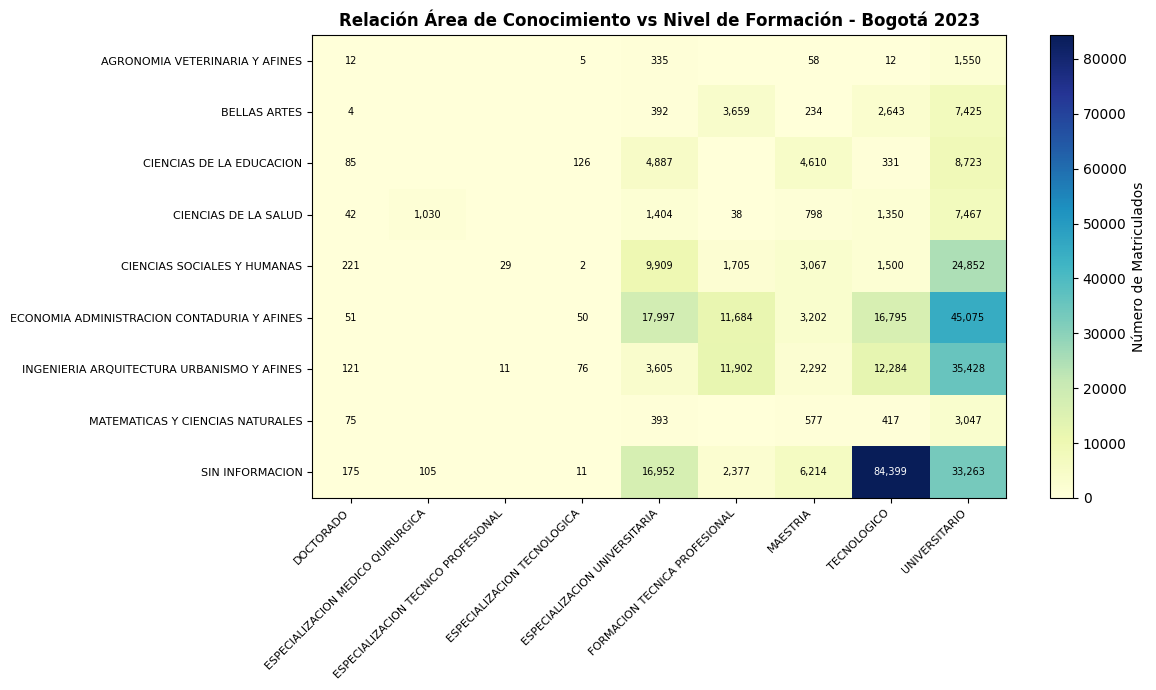

In [38]:
# Crear figura y mapa de calor
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(tabla_cruzada.values, cmap="YlGnBu", aspect="auto")

# Configurar etiquetas de ejes
ax.set_xticks(range(len(tabla_cruzada.columns)))
ax.set_xticklabels(tabla_cruzada.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(tabla_cruzada.index)))
ax.set_yticklabels(tabla_cruzada.index, fontsize=8)

# Escribir los valores dentro de las celdas (cambiando color de texto según contraste)
for i in range(tabla_cruzada.shape[0]):
    for j in range(tabla_cruzada.shape[1]):
        valor = tabla_cruzada.values[i, j]
        if valor > 0:
            ax.text(j, i, f"{valor:,.0f}", ha="center", va="center", fontsize=7,
                    color="black" if valor < tabla_cruzada.values.max() * 0.6 else "white")

# Título, barra de color y mostrar
ax.set_title("Relación Área de Conocimiento vs Nivel de Formación - Bogotá 2023",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, label="Número de Matriculados")
plt.tight_layout()
plt.show()

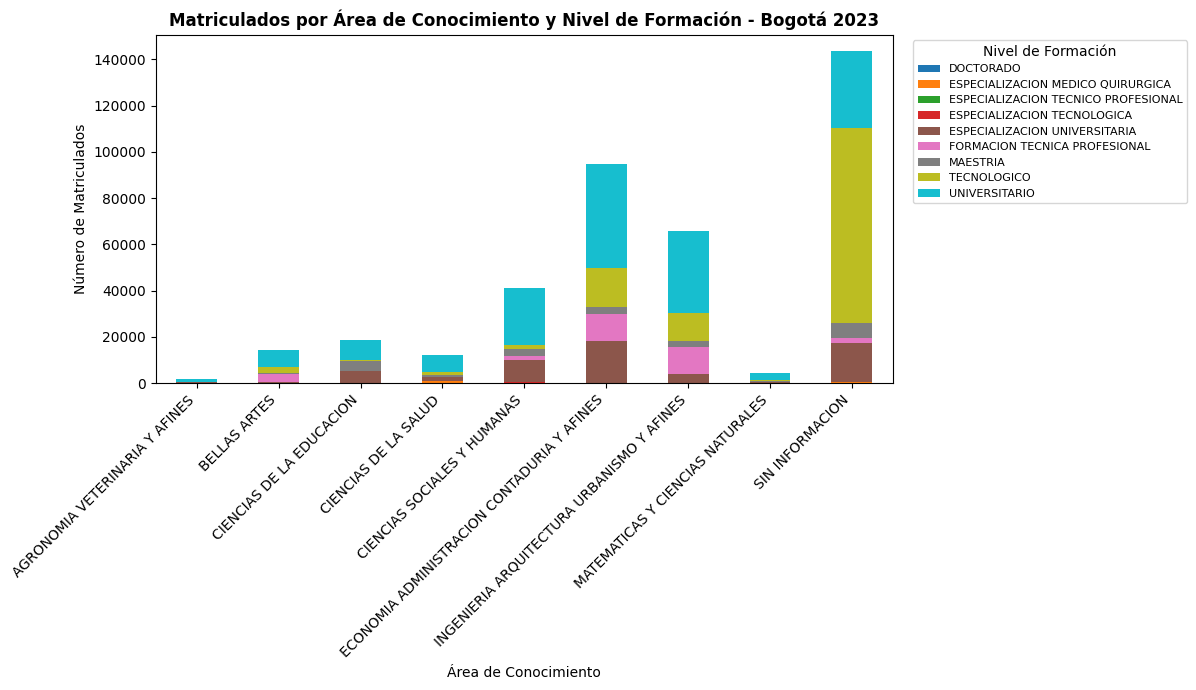


Chi-cuadrado: 172,658.93
Valor p: 0.0000000000
Grados de libertad: 64


In [44]:
# Crear figura y ejes
fig, ax = plt.subplots(figsize=(12, 7))

# Crear el gráfico de barras apiladas
tabla_cruzada.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")

# Configurar título y etiquetas de ejes
ax.set_title("Matriculados por Área de Conocimiento y Nivel de Formación - Bogotá 2023",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Área de Conocimiento")
ax.set_ylabel("Número de Matriculados")

# Rotar etiquetas del eje X para mejorar legibilidad
plt.xticks(rotation=45, ha="right")

# Posicionar la leyenda fuera del área del gráfico (a la derecha)
ax.legend(title="Nivel de Formación", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

from scipy.stats import chi2_contingency

chi2, p_valor, gl, esperado = chi2_contingency(tabla_cruzada)
print(f"\nChi-cuadrado: {chi2:,.2f}")
print(f"Valor p: {p_valor:.10f}")
print(f"Grados de libertad: {gl}")

In [ ]:
#✅ Limpieza de datos: función para quitar tildes/ñ, caracteres especiales y pasar a mayúsculas
#✅ Filtro de la base a Bogotá y año 2023
#✅ Pregunta 1: matriculados por nivel de formación (gráfico de barras)
#✅ Pregunta 2: distribución por sexo (gráfico circular)
#✅ Pregunta 3: relación área de conocimiento vs nivel de formación (mapa de calor + barras apiladas)
#✅ Código entregado como script .py y luego reescrito celda a celda para Google Colab



#❌ Planteamiento del problema y objetivo formal del proyecto (redactado)
#❌ Descripción/comprensión formal del conjunto de datos (variables, tipos, valores faltantes)
#❌ Análisis estadístico (pruebas de hipótesis, significancia) — solo había EDA descriptivo, sin pruebas como Chi-cuadrado
#❌ Un modelo (supervisado o no supervisado) — no existía ninguna sección de "selección, aplicación y evaluación de modelo";
# solo eran gráficos descriptivos
#❌ Informe escrito completo (documento Word) que uniera todo el proceso con explicación de decisiones
#❌ Presentación (PowerPoint) para la sustentación
#❌ README con estructura del repositorio e instrucciones
#❌ Estructura de repositorio de GitHub organizada

In [42]:
from scipy.stats import chi2_contingency

chi2, p_valor, gl, esperado = chi2_contingency(tabla_cruzada)
print(f"Chi-cuadrado: {chi2:,.2f}")
print(f"Valor p: {p_valor:.10f}")
print(f"Grados de libertad: {gl}")

Chi-cuadrado: 172,658.93
Valor p: 0.0000000000
Grados de libertad: 64


In [45]:
print(df_bog.columns.tolist())

['CÓDIGO DE LA INSTITUCIÓN', 'IES PADRE', 'INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)', 'TIPO IES', 'ID SECTOR IES', 'SECTOR IES', 'ID CARÁCTER IES', 'CARÁCTER IES', 'CÓDIGO DEL DEPARTAMENTO (IES)', 'DEPARTAMENTO DE DOMICILIO DE LA IES', 'CÓDIGO DEL MUNICIPIO IES', 'MUNICIPIO DE DOMICILIO DE LA IES', 'IES ACREDITADA', 'CÓDIGO SNIES DEL PROGRAMA', 'PROGRAMA ACADÉMICO', 'PROGRAMA ACREDITADO', 'ID NIVEL ACADÉMICO', 'NIVEL ACADÉMICO', 'ID NIVEL DE FORMACIÓN', 'NIVEL DE FORMACIÓN', 'ID MODALIDAD', 'MODALIDAD', 'ID ÁREA', 'ÁREA DE CONOCIMIENTO', 'ID NÚCLEO', 'NÚCLEO BÁSICO DEL CONOCIMIENTO (NBC)', 'ID CINE CAMPO AMPLIO', 'DESC CINE CAMPO AMPLIO', 'ID CINE CAMPO ESPECIFICO', 'DESC CINE CAMPO ESPECIFICO', 'ID CINE CAMPO DETALLADO', 'DESC CINE CAMPO DETALLADO', 'CÓDIGO DEL DEPARTAMENTO (PROGRAMA)', 'DEPARTAMENTO DE OFERTA DEL PROGRAMA', 'CÓDIGO DEL MUNICIPIO (PROGRAMA)', 'MUNICIPIO DE OFERTA DEL PROGRAMA', 'ID SEXO', 'SEXO', 'AÑO', 'SEMESTRE', 'MATRICULADOS PRIMER CURSO', 'MUNICIPIO DE OFERTA DEL 

Registros disponibles para el modelo: 12,056
Entrenamiento: 9,644 | Prueba: 2,412
MAE:  30.83
RMSE: 123.21
R²:   0.179


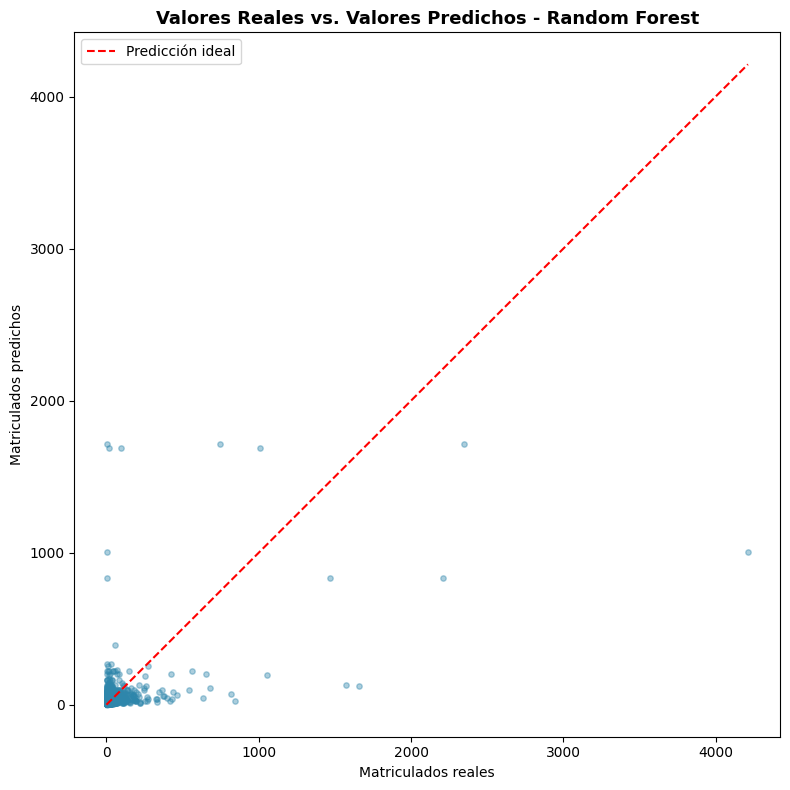

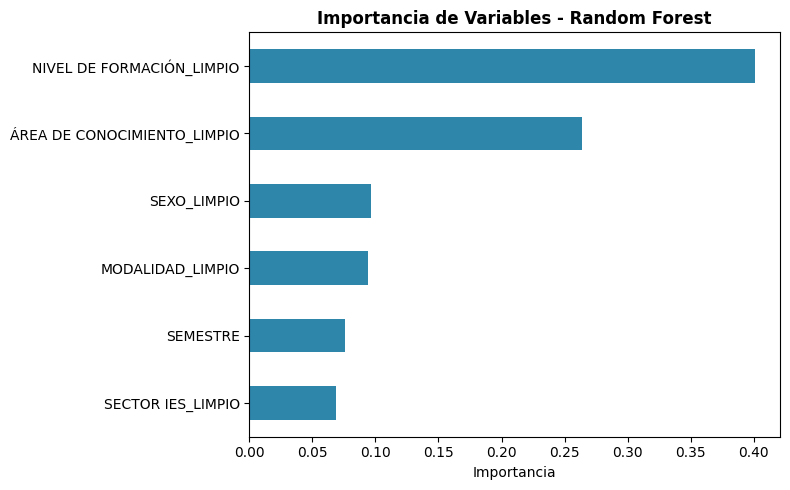

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- 0. Limpieza rápida de las columnas que faltaban normalizar ---
df_bog["SECTOR IES_LIMPIO"] = df_bog["SECTOR IES"].apply(limpiar_texto)
df_bog["MODALIDAD_LIMPIO"] = df_bog["MODALIDAD"].apply(limpiar_texto)

# --- 1. Selección de variables predictoras y variable objetivo ---
columnas_predictoras = [
    "NIVEL DE FORMACIÓN_LIMPIO",
    "SEXO_LIMPIO",
    "ÁREA DE CONOCIMIENTO_LIMPIO",
    "SEMESTRE",
    "SECTOR IES_LIMPIO",
    "MODALIDAD_LIMPIO",
]
variable_objetivo = "MATRICULADOS PRIMER CURSO"

# Dataframe de trabajo, solo con las columnas necesarias y sin nulos
df_modelo = df_bog[columnas_predictoras + [variable_objetivo]].dropna()
print(f"Registros disponibles para el modelo: {len(df_modelo):,}")

# --- 2. Codificación de variables categóricas a números ---
# SEMESTRE ya es numérica, así que la excluimos de la codificación ordinal
columnas_categoricas = [
    "NIVEL DE FORMACIÓN_LIMPIO",
    "SEXO_LIMPIO",
    "ÁREA DE CONOCIMIENTO_LIMPIO",
    "SECTOR IES_LIMPIO",
    "MODALIDAD_LIMPIO",
]

encoder = OrdinalEncoder()
X = df_modelo[columnas_predictoras].copy()
X[columnas_categoricas] = encoder.fit_transform(X[columnas_categoricas])
y = df_modelo[variable_objetivo]

# --- 3. División en entrenamiento (80%) y prueba (20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}")

# --- 4. Entrenamiento del modelo ---
modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# --- 5. Predicción y métricas de evaluación ---
y_pred = modelo_rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:,.3f}")

# --- 6. Gráfico: valores reales vs. valores predichos ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.4, color="#2E86AB", s=15)

limite_max = max(y_test.max(), y_pred.max())
ax.plot([0, limite_max], [0, limite_max], "r--", linewidth=1.5, label="Predicción ideal")

ax.set_title("Valores Reales vs. Valores Predichos - Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Matriculados reales")
ax.set_ylabel("Matriculados predichos")
ax.legend()
plt.tight_layout()
plt.show()

# --- 7. Importancia de variables ---
importancias = pd.Series(modelo_rf.feature_importances_, index=columnas_predictoras).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Importancia de Variables - Random Forest", fontsize=12, fontweight="bold")
ax.set_xlabel("Importancia")
ax.invert_yaxis()
plt.tight_layout()
plt.show()